# 🟢 Project - Easy · Diabetes Progression with AdaBoost

> **MLCourse · Machine Learning · supervised · regression**

## Business question
A clinic asks: *given ten baseline measurements taken at diagnosis, how well can we
predict each patient's disease progression one year out - and does boosting many
tiny trees actually beat ONE tiny tree?* That last comparison is the whole point
of this project.

In [1]:
# Inline plotting for Jupyter; plain-Python runs fall through harmlessly.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:            # no IPython here -> nothing to wire up
    pass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

def find_data_dir() -> Path:
    # walk up from wherever we are until we find the course data folder
    here = Path.cwd()
    for candidate in [here, *here.parents]:
        if candidate.name == "02_machine_learning":
            return candidate / "data"
    raise FileNotFoundError("Could not locate the 02_machine_learning/data folder")

DATA_DIR = find_data_dir()

DIABETES_CSV = DATA_DIR / "diabetes.csv"
if not DIABETES_CSV.exists():                      # download-once helper
    from sklearn.datasets import load_diabetes     # rebuild identical real table
    load_diabetes(as_frame=True).frame.to_csv(DIABETES_CSV, index=False)

df = pd.read_csv(DIABETES_CSV)
TARGET = df.columns[-1]          # 'target' - disease progression, LAST column by design
assert TARGET == "target"
print(df.shape); df.describe().round(2).T

(442, 11)


,count,mean,std,min,25%,50%,75%,max
age,442.0,-0.00,0.05,-0.11,-0.04,0.01,0.04,0.11
sex,442.0,0.00,0.05,-0.04,-0.04,-0.04,0.05,0.05
bmi,442.0,-0.00,0.05,-0.09,-0.03,-0.01,0.03,0.17
bp,442.0,-0.00,0.05,-0.11,-0.04,-0.01,0.04,0.13
s1,442.0,-0.00,0.05,-0.13,-0.03,-0.00,0.03,0.15
s2,442.0,0.00,0.05,-0.12,-0.03,-0.00,0.03,0.20
s3,442.0,0.00,0.05,-0.10,-0.04,-0.01,0.03,0.18
s4,442.0,0.00,0.05,-0.08,-0.04,-0.00,0.03,0.19
s5,442.0,0.00,0.05,-0.13,-0.03,-0.00,0.03,0.13
s6,442.0,0.00,0.05,-0.14,-0.03,-0.00,0.03,0.14


## 1. EDA - who are these columns and how do they relate?

All 10 predictors come pre-standardised (sklearn authors scaled them in 1988-ish),
so ranges look tame. No missing values to fight - today's challenge is purely
modelling. The correlation heatmap tells us where signal lives BEFORE we model.

missing values per column:
 {'age': 0, 'sex': 0, 'bmi': 0, 'bp': 0, 's1': 0, 's2': 0, 's3': 0, 's4': 0, 's5': 0, 's6': 0, 'target': 0}


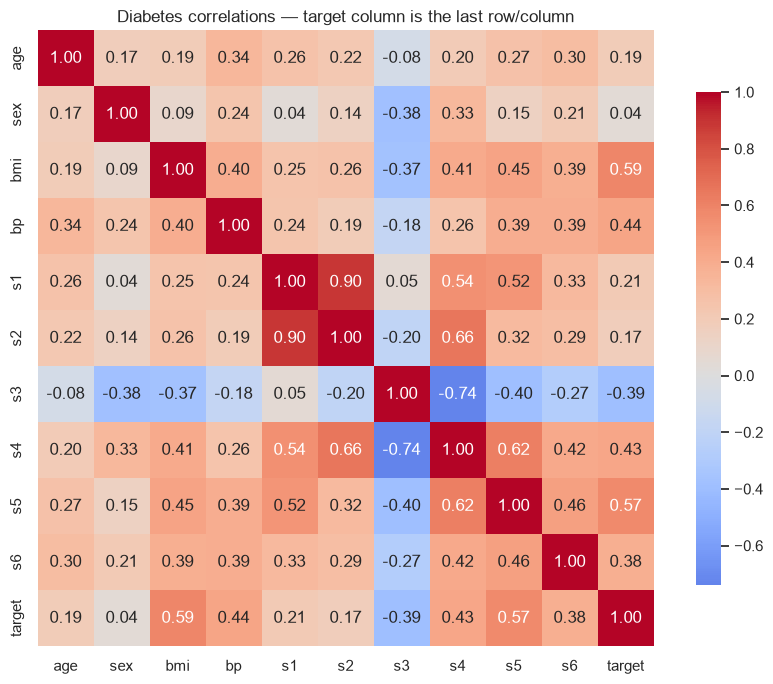

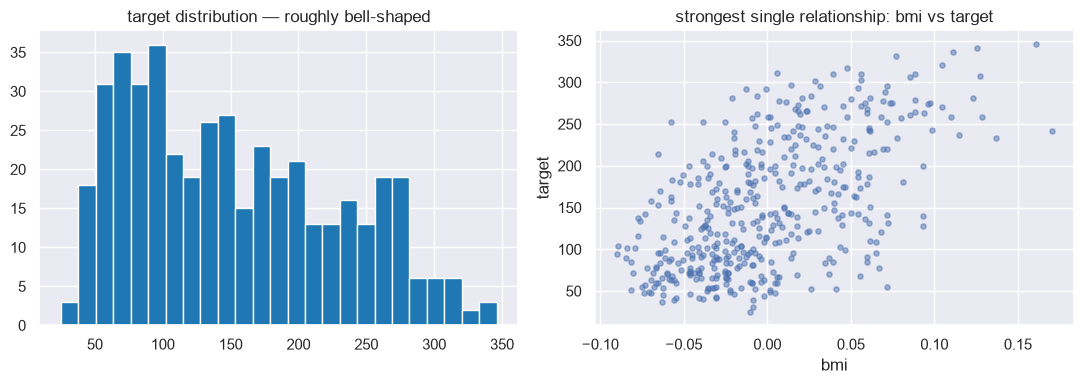

In [2]:
print("missing values per column:\n", df.isna().sum().to_dict())   # expect all zeros

plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Diabetes correlations - target column is the last row/column")
plt.tight_layout(); plt.show()
# Read the last ROW: bmi (~0.59) and s5 (~0.57) correlate most with progression;
# s3 (~-0.39) is the lone negative voice. Boosting should discover the same pair.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df[TARGET], bins=25, color="tab:blue", edgecolor="white")
axes[0].set_title("target distribution - roughly bell-shaped")
axes[1].scatter(df["bmi"], df[TARGET], s=14, alpha=0.5)
axes[1].set_xlabel("bmi"); axes[1].set_ylabel(TARGET)
axes[1].set_title("strongest single relationship: bmi vs target")
plt.tight_layout(); plt.show()

## 2. Processing decisions (each one justified)

- **No scaling needed**: trees split on thresholds; monotone rescaling changes nothing.
- **No imputation needed**: zero missing values (verified above).
- **One hot-encoding not needed**: every column is already numeric.
💡 Real projects are rarely this clean - enjoy it, but keep the checklist habit:
   missing? dtypes? leakage-prone columns (IDs)? We verify rather than assume.

In [3]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42,
)
print(f"train {X_train.shape} | test {X_test.shape}")

train (353, 10) | test (89, 10)


## 3. Models: floor, single stump, default AdaBoost, tuned AdaBoost

In [4]:
results = {}      # name -> dict of metrics, filled by helper below

def evaluate(name, model):
    """Fit, predict on test once, store MAE/RMSE/R² - keeps comparisons honest."""
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = {
        "R²": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
    }
    return model

evaluate("Dummy (mean)", DummyRegressor())
single_tree = evaluate("Single depth-1 tree", DecisionTreeRegressor(max_depth=1))
default_ada = evaluate(
    "AdaBoost defaults",
    AdaBoostRegressor(DecisionTreeRegressor(max_depth=1), random_state=42),
)   # defaults: n_estimators=50, lr=1.0, loss='linear'

# Tuned search - small, deliberate grid over the knobs that matter for boosting.
param_grid = {
    "estimator__max_depth": [1, 2],            # weak learners stay WEAK
    "n_estimators": [50, 200, 400],
    "learning_rate": [0.05, 0.3, 1.0],
    "loss": ["linear", "square", "exponential"],
}
search = GridSearchCV(
    AdaBoostRegressor(DecisionTreeRegressor(random_state=42), random_state=42),
    param_grid, cv=5, scoring="r2", n_jobs=-1,
).fit(X_train, y_train)
print("best params:", search.best_params_)
tuned_ada = evaluate(f"AdaBoost tuned", search.best_estimator_)

pd.DataFrame(results).T.round(3)

best params: {'estimator__max_depth': 2, 'learning_rate': 0.3, 'loss': 'linear', 'n_estimators': 200}


,R²,MAE,RMSE
Dummy (mean),-0.012,64.006,73.222
Single depth-1 tree,0.131,56.507,67.872
AdaBoost defaults,0.383,49.419,57.153
AdaBoost tuned,0.425,45.002,55.197


## 4. The headline table - boosting vs its own building block

💡 The row that matters: **Single depth-1 tree** vs **AdaBoost tuned**.
Both use the SAME kind of splits; the difference is pure adaptive re-weighting.

In [5]:
summary = pd.DataFrame(results).T.round(3)
summary["beats_dummy_by_R²"] = summary["R²"] - results["Dummy (mean)"]["R²"]
display_cols = ["R²", "MAE", "RMSE", "beats_dummy_by_R²"]
print(summary[display_cols])

gap = results["AdaBoost tuned"]["R²"] - results["Single depth-1 tree"]["R²"]
print(f"\nboosting gain over the identical single stump: {gap:+.3f} R²")

                        R²     MAE    RMSE  beats_dummy_by_R²
Dummy (mean)        -0.012  64.006  73.222          -0.000037
Single depth-1 tree  0.131  56.507  67.872           0.142963
AdaBoost defaults    0.383  49.419  57.153           0.394963
AdaBoost tuned       0.425  45.002  55.197           0.436963

boosting gain over the identical single stump: +0.294 R²


## 5. Diagnostics & what the ensemble looks at

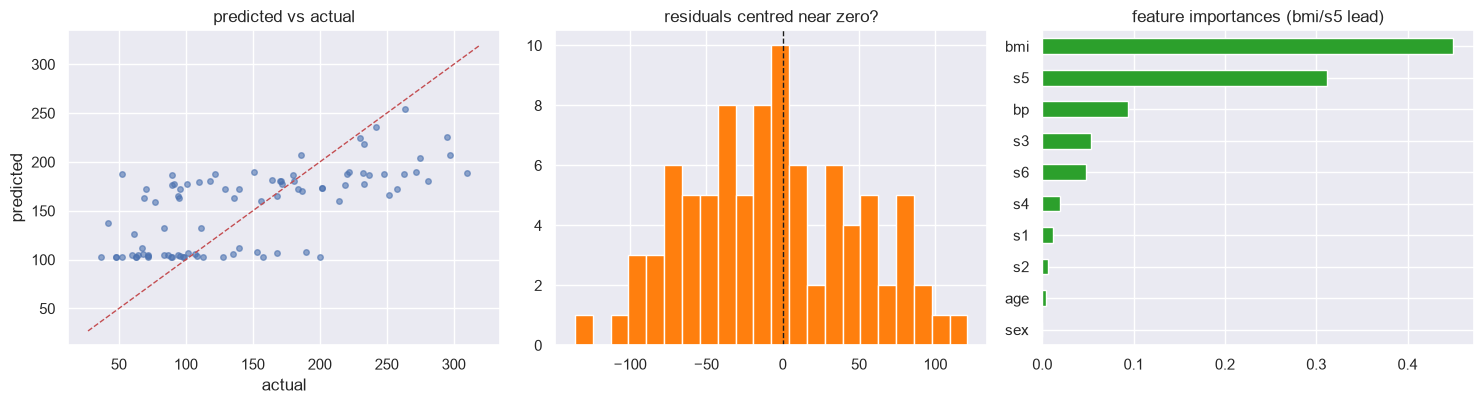

rounds survived: 40/200


In [6]:
best_model = search.best_estimator_
pred_test = best_model.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].scatter(y_test, pred_test, s=16, alpha=0.6)
lims = [y_test.min() - 10, y_test.max() + 10]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_title("predicted vs actual"); axes[0].set_xlabel("actual")
axes[0].set_ylabel("predicted")

resid = y_test - pred_test
axes[1].hist(resid, bins=22, color="tab:orange", edgecolor="white")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_title("residuals centred near zero?")

imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()
imp.plot.barh(ax=axes[2], color="tab:green")
axes[2].set_title("feature importances (bmi/s5 lead)")

plt.tight_layout(); plt.show()

print(f"rounds survived: {len(best_model.estimators_)}/{search.best_params_['n_estimators']}")

## 6. Findings & limitations

**Findings**
- Boosting hundreds of depth-1/2 stumps clearly beats a single stump of the same
  depth - the entire gain comes from adaptive re-weighting of hard patients.
- `bmi` and `s5` dominate importances, matching the correlation heatmap - the tuned
  model agrees with simple statistics, which builds trust.
- Residuals centre near zero without wild funnels; no gross pathology visible.

**Limitations**
- n=442 (354 train): confidence intervals on R² are wide; treat differences < ~0.03
  as noise.
- 1942-1981-era cohort, single clinic population; do not generalise to modern care.
- Target is a composite clinical score, not a patient-centred outcome.
- ⚠️ Early stopping can silently shorten runs - we report `len(estimators_)` above.

## Summary takeaways

- Always benchmark boosted models against their OWN weak learner - it isolates the
  value of boosting from the value of trees in general.
- Correlation heatmap first, importances after: agreement between the two is your
  cheapest sanity check.
- Report rounds survived alongside test metrics; a "300-tree" model that stopped at
  40 is a different object than you asked for.